In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
print(platform)
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

# from jax import config
# import scipy.interpolate as interp
import pickle as pk
import numpy as np
# import colossus 
# import configobj

# from base_class import base_class
# from get_radial_profiles import Profiles
# from get_Pkzs import get_Pkz
# from get_Cls import get_Cl
# from get_Xis import get_xi
# from get_covs import get_cov


import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline






/tmp/ipykernel_437231/3901941352.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


gpu
1 1


In [2]:
import joblib
# df = joblib.load(open('Pk_data.pkl','rb'))
df = joblib.load(open('Pk_data_sup.pkl','rb'))
print(df.keys())


dict_keys(['Mead20', 'Schneider19', 'Arico20', 'sim'])


In [3]:
df['sim'].keys()


dict_keys(['m-m', 'm-p'])

In [4]:
df = joblib.load(open('Pk_data_sup.pkl','rb'))
# df['sim']['m-m'][0].shape, df['sim']['m-m'][1].shape,df['sim']['m-m'][2].shape
df['sim']['m-p'][0].shape, df['sim']['m-p'][1].shape,df['sim']['m-p'][2].shape


((100,), (100,), (100,))

In [5]:
len(df['Schneider19']['m-m'])

4

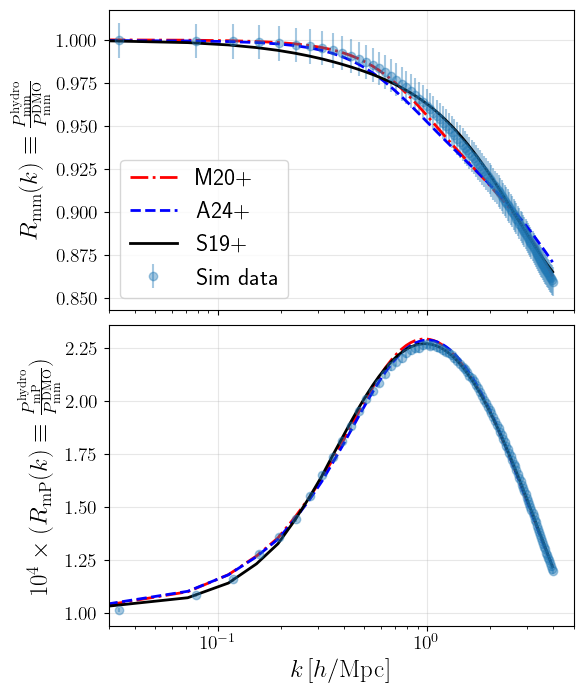

In [25]:
# df['sim']
sim_data = df['sim']
A20 = df['Arico20']
M20 = df['Mead20']
S19 = df['Schneider19']

fig, ax = plt.subplots(2, 1, figsize=(6,8), sharex=True)
# set vertical space between subplots:
fig.subplots_adjust(hspace=0.05)

for jp in range(2):
    if jp == 0:
        key = 'm-m'
        fac = 1
    else:
        key = 'm-p'
        fac = 10000
    ax[jp].errorbar(sim_data[key][0], fac*(sim_data[key][1]/sim_data[key][2]),yerr=0.01*fac*(sim_data[key][1]/sim_data[key][2]), ls='', marker='o', label='Sim data', alpha=0.4)
    ax[jp].plot(M20[key][0], fac*M20[key][1], '-.', lw=2.0, label='M20+', color='r')
    ax[jp].plot(A20[key][0], fac*A20[key][1], '--', lw=2.0,label='A24+', color='b')
    ax[jp].plot(S19[key][0], fac*S19[key][1], '-', lw=2.0,label='S19+', color='k')


for ji in range(2):
    ax[ji].set_xscale('log')
    ax[ji].set_xlim(3e-2, 5)
    ax[ji].grid(alpha=0.3)
    # set the ticks label sizes:
    ax[ji].tick_params(axis='both', which='major', labelsize=14)
    if ji == 0:
        ax[ji].set_ylabel(r'$R_{\rm mm}(k) \equiv \frac{P^{\rm hydro}_{\rm mm}}{P^{\rm DMO}_{\rm mm}}$', fontsize=18)
        ax[ji].legend(fontsize=17)
    if ji == 1:
        ax[ji].set_xlabel(r'$k \, [h/\mathrm{Mpc}]$', fontsize=18)
        ax[ji].set_ylabel(r'$10^4 \times (R_{\rm mP}(k) \equiv \frac{P^{\rm hydro}_{\rm mP}}{P^{\rm DMO}_{\rm mm}})$', fontsize=18)




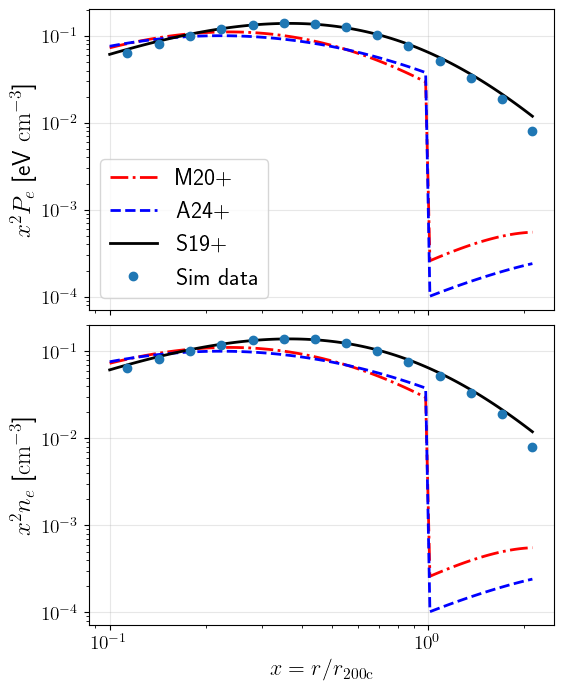

In [28]:
# fig, ax = plt.subplots(2, 1, figsize=(5,9), sharex=True)
fig, ax = plt.subplots(2, 1, figsize=(6,8), sharex=True)
# set vertical space between subplots:
fig.subplots_adjust(hspace=0.05)

for jp in range(2):
    if jp == 0:
        data = joblib.load(open('data_dict_Pe.pkl','rb'))
    else:
        data = joblib.load(open('data_dict_Pe.pkl','rb'))
    pw=2
    ax[jp].errorbar(data['sim'][0][1], (data['sim'][0][1]**pw)*data['sim'][1][1], ls='', marker='o', label='Sim data', alpha=1.0)
    ax[jp].plot(data['M20'][0], (data['M20'][0]**pw)*data['M20'][1][3], '-.', lw=2.0, label='M20+', color='r')
    ax[jp].plot(data['A20'][0], (data['A20'][0]**pw)*data['A20'][1][3], '--', lw=2.0,label='A24+', color='b')
    ax[jp].plot(data['S19'][0], (data['S19'][0]**pw)*data['S19'][1][3], '-', lw=2.0,label='S19+', color='k')


for ji in range(2):
    ax[ji].set_xscale('log')
    ax[ji].set_yscale('log')
    ax[ji].grid(alpha=0.3)
    # ax[ji].set_xlim(3e-2, 5)
    ax[ji].tick_params(axis='both', which='major', labelsize=14)
    if ji == 0:
        ax[ji].set_ylabel(r'$x^2 P_e$ [eV ${\rm cm}^{-3}$]', fontsize=18)
        ax[ji].legend(fontsize=17)
    if ji == 1:
        ax[ji].set_xlabel(r'$x = r/r_{\rm 200c}$', fontsize=16)
        ax[ji].set_ylabel(r'$x^2 n_e$ [${\rm cm}^{-3}$]', fontsize=18)




In [ ]:
data = joblib.load(open('data_dict_Pe.pkl','rb'))
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# 1st index is to specify x/profile; 2nd index for mass bin
# log mass bins edges (13, 13.5) & (14.5, 15)
ax[0].loglog(data['sim'][0][0], data['sim'][1][0], 'kh--', mfc='None')
ax[1].loglog(data['sim'][0][1], data['sim'][1][1]*15, 'kh--', mfc='k')


ax[0].loglog(data['M20'][0], data['M20'][1][0], label='M20')
ax[1].loglog(data['M20'][0], data['M20'][1][3]*15)

ax[0].loglog(data['S19'][0], data['S19'][1][0], label='S19')
ax[1].loglog(data['S19'][0], data['S19'][1][3]*15)

ax[0].loglog(data['A20'][0], data['A20'][1][0], label='A20')
ax[1].loglog(data['A20'][0], data['A20'][1][3]*15)

ax[0].legend()


([array([0.11363555, 0.14249382, 0.17875231, 0.22431915, 0.28107996,
         0.35245119, 0.4419552 , 0.55398045, 0.69409152, 0.86960561,
         1.08952378, 1.36480471, 1.71011395, 2.14544056]),
  array([0.11373902, 0.14262709, 0.17880226, 0.22411105, 0.28083465,
         0.35189034, 0.44077565, 0.55192972, 0.69111267, 0.86561175,
         1.08456766, 1.36020149, 1.70115153, 2.11439561])],
 [array([0.19096768, 0.15978279, 0.13353574, 0.10888627, 0.08420248,
         0.06405204, 0.04632022, 0.03117185, 0.01966514, 0.0117393 ,
         0.00657957, 0.00347491, 0.00176414, 0.00089937]),
  array([4.93327956e+00, 4.01496336e+00, 3.15480618e+00, 2.37841785e+00,
         1.69740494e+00, 1.13778703e+00, 7.14540451e-01, 4.10904661e-01,
         2.14018353e-01, 1.01429208e-01, 4.40310073e-02, 1.78298774e-02,
         6.56370207e-03, 1.78666863e-03])])

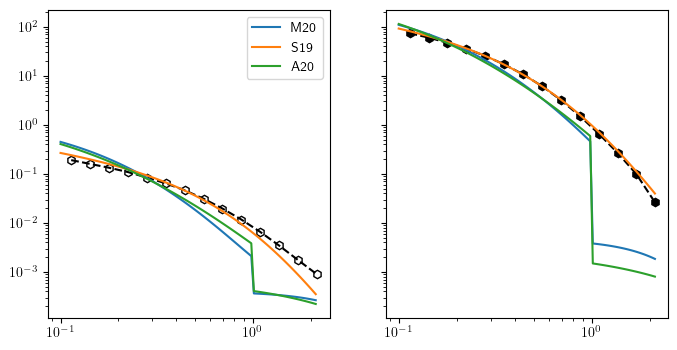

In [38]:
data = joblib.load(open('data_dict_Pe.pkl','rb'))
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# 1st index is to specify x/profile; 2nd index for mass bin
# log mass bins edges (13, 13.5) & (14.5, 15)
ax[0].loglog(data['sim'][0][0], data['sim'][1][0], 'kh--', mfc='None')
ax[1].loglog(data['sim'][0][1], data['sim'][1][1]*15, 'kh--', mfc='k')


ax[0].loglog(data['M20'][0], data['M20'][1][0], label='M20')
ax[1].loglog(data['M20'][0], data['M20'][1][3]*15)

ax[0].loglog(data['S19'][0], data['S19'][1][0], label='S19')
ax[1].loglog(data['S19'][0], data['S19'][1][3]*15)

ax[0].loglog(data['A20'][0], data['A20'][1][0], label='A20')
ax[1].loglog(data['A20'][0], data['A20'][1][3]*15)

ax[0].legend()


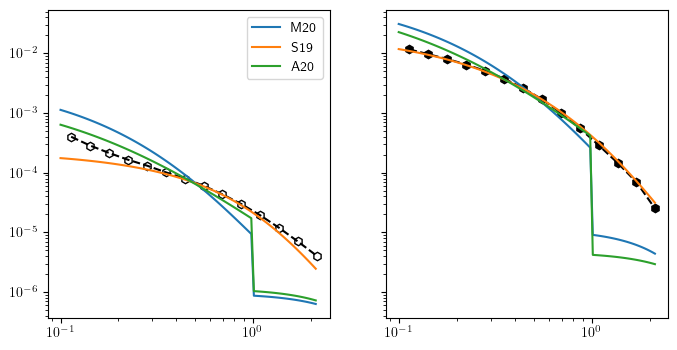

In [50]:
data = joblib.load(open('data_dict_ne.pkl','rb'))
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# 1st index is to specify x/profile; 2nd index for mass bin
# log mass bins edges (13, 13.5) & (14.5, 15)
ax[0].loglog(data['sim'][0][0], data['sim'][1][0], 'kh--', mfc='None')
ax[1].loglog(data['sim'][0][1], data['sim'][1][1]*15, 'kh--', mfc='k')


ax[0].loglog(data['M20'][0], data['M20'][1][0], label='M20')
ax[1].loglog(data['M20'][0], data['M20'][1][3]*15)

ax[0].loglog(data['S19'][0], data['S19'][1][0], label='S19')
ax[1].loglog(data['S19'][0], data['S19'][1][3]*15)

ax[0].loglog(data['A20'][0], data['A20'][1][0], label='A20')
ax[1].loglog(data['A20'][0], data['A20'][1][3]*15)

ax[0].legend()


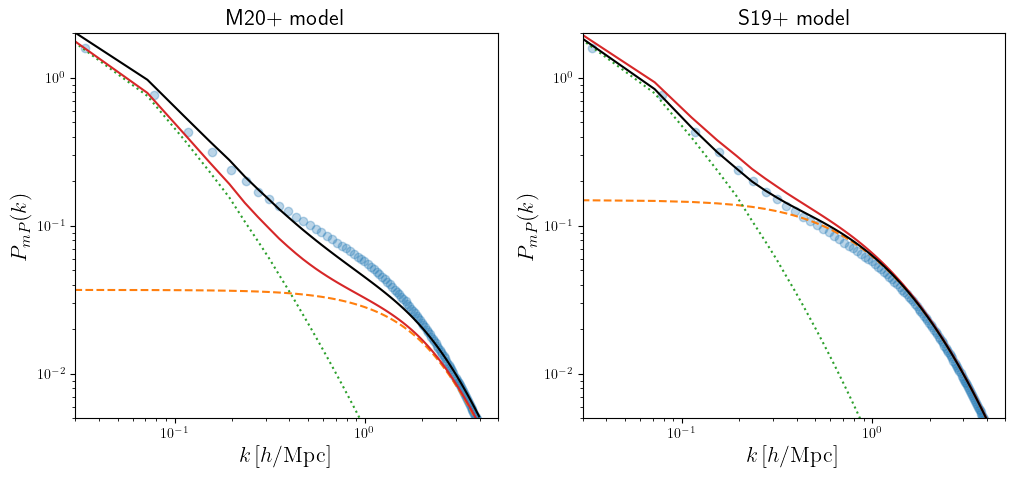

In [14]:
# df['sim']
sim_data = df['sim']
A20 = df['Arico20']
al_a20 = 0.6

M20 = df['Mead20']
al_m20 = 0.6

S19 = df['Schneider19']
al_s19 = 1.4
# plt.figure(figsize=(6,5))
# make a 2x1 figure:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
# fac = sim_data[0]
fac = 1
ax[0].plot(sim_data[0], fac*sim_data[1], 'o', label='Sim data', alpha=0.3)
ax[1].plot(sim_data[0], fac*sim_data[1], 'o', label='Sim data', alpha=0.3)
# plt.plot(A20[0], A20[2], '-', label='Arico+20 fit')
# plt.plot(A20[0], A20[3], '-', label='Arico+20 fit')
# plt.plot(A20[0], A20[2] + A20[3], '-', label='Arico+20 fit')
# plt.plot(A20[0], (A20[2]**al_a20 + A20[3]**al_a20)**(1/al_a20), '-', label='Arico+20 fit')


# fac = S19[0]
# plt.plot(S19[0], fac*S19[2], '-', label='Schneider+19 fit')
# plt.plot(S19[0], fac*S19[3], '-', label='Schneider+19 fit')
# plt.plot(S19[0], fac*(S19[2]+S19[3]), '-', label='Schneider+19 fit')
# plt.plot(S19[0], fac*((S19[2]**al_s19+S19[3]**al_s19)**(1/al_s19)), '-', label='Schneider+19 fit')

# fac = M20[0]
fac = 1
ax[0].plot(M20[0], fac*M20[2], '--', label='Mead+20 fit')
ax[0].plot(M20[0], fac*M20[3], ':', label='Mead+20 fit')
ax[0].plot(M20[0], fac*(M20[2]+M20[3]), '-', label='Mead+20 fit')
ax[0].plot(M20[0], fac*((M20[2]**al_m20 + M20[3]**al_m20)**(1/al_m20)), '-', color='k',label='Mead+20 fit')
ax[0].set_title('M20+ model', fontsize=16)

ax[1].plot(S19[0], fac*S19[2], '--', label='Schneider+19 fit')
ax[1].plot(S19[0], fac*S19[3], ':', label='Schneider+19 fit')
ax[1].plot(S19[0], fac*(S19[2]+S19[3]), '-', label='Schneider+19 fit')
ax[1].plot(S19[0], fac*((S19[2]**al_s19+S19[3]**al_s19)**(1/al_s19)), '-', color='k', label='Schneider+19 fit')
ax[1].set_title('S19+ model', fontsize=16)

for ji in range(2):
    ax[ji].set_xscale('log')
    ax[ji].set_yscale('log')
    ax[ji].set_ylim(5e-3, 2)
    ax[ji].set_xlim(3e-2, 5)
    ax[ji].set_xlabel(r'$k \, [h/\mathrm{Mpc}]$', fontsize=16)
    ax[ji].set_ylabel(r'$P_{mP}(k)$', fontsize=16)




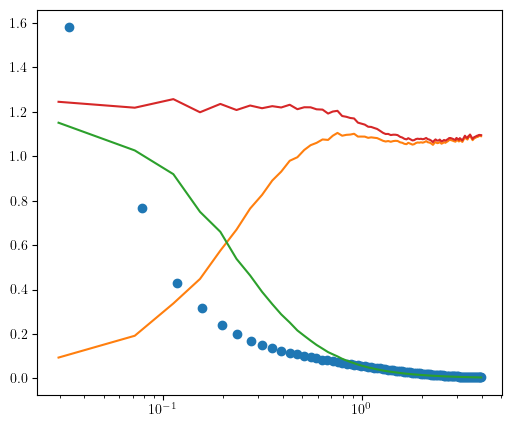

In [17]:
# df['sim']
sim_data = df['sim']
A20 = df['Arico20']
M20 = df['Mead20']
S19 = df['Schneider19']
plt.figure(figsize=(6,5))
plt.plot(sim_data[0], sim_data[1], 'o', label='Sim data')
# plt.plot(A20[0], A20[1], '-', label='Arico+20 fit')
# plt.plot(A20[0], A20[2], '-', label='Arico+20 fit')
# plt.plot(A20[0], A20[3], '-', label='Arico+20 fit')
# plt.plot(A20[0], A20[2] + A20[3], '-', label='Arico+20 fit')

plt.plot(S19[0], S19[2]/sim_data[1], '-', label='Schneider+19 fit')
plt.plot(S19[0], S19[3]/sim_data[1], '-', label='Schneider+19 fit')
plt.plot(S19[0], (S19[2]+S19[3])/sim_data[1], '-', label='Schneider+19 fit')

# plt.plot(M20[0], M20[2], '-', label='Mead+20 fit')
# plt.plot(M20[0], M20[3], '-', label='Mead+20 fit')
# plt.plot(M20[0], M20[2]+M20[3], '-', label='Mead+20 fit')

plt.xscale('log')
# plt.yscale('log')


In [2]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
import yaml
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

        

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj
import copy
import yaml
from deepmerge import always_merger
import ast 

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov

import jax_cosmo.background as bkgrd
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
import yaml
from deepmerge import always_merger
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
import jax_cosmo.background as bkgrd
import getdist
from getdist import plots, MCSamples
from tqdm import tqdm
import ast
import argparse
from scipy.interpolate import interp1d
import astropy.units as u
from astropy import constants as const
import warnings
warnings.filterwarnings("ignore")

def get_samps(fname, param_acorr='sigma8', true_val=0.8, ess_thresh = 100, acorr_min=0.035, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.0, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
    
    # acorr = autocorrelation(sig8_rs, axis=1)
    # ind_del = []
    # for ji in range(acorr.shape[0]):
    #     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
    #         ind_del.append(ji)    

    ess_per_chain = effective_sample_size(jnp.asarray(sig8_rs))
    
    ind_del = []
    for jc in range(nchains):
        ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
        if ess_jc < ess_thresh:
            ind_del.append(jc)  
        else:
            if np.abs(np.mean(sig8_rs[jc,:]) - true_val)/np.std(sig8_rs[jc,:]) > 5:
                ind_del.append(jc)      
            
    
    ind_del = np.array(ind_del)    

    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys


def get_dicts_default():
    
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    # sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
    new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    # analysis_dict['beam_fwhm_arcmin'] = 1.4
    df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
    zarray_comoving = df_nz_comoving[:,0]
    nz_comoving_orig = df_nz_comoving[:,1]
    indsel = np.where(zarray_comoving < 0.4)[0]
    nz_comoving = np.zeros_like(zarray_comoving)
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    indsel = np.where(zarray_comoving > 0.4)[0]
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
    analysis_dict['nbar_gal_comoving_val'] = nz_comoving
    
    
    
    from scipy.interpolate import interp1d
    # ks = np.geomspace(5e-2,50,15) # wavenumbers
    ks = np.geomspace(3e-1,10,10) # wavenumbers
    zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
    zarray_lens = np.linspace(0.001, 1.6, 100)
    nbins_lens = len(zedges) - 1
    
    cosmo_params = sim_params_dict.get('cosmo')
    cosmo_jax = Cosmology(
                Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
                Omega_b=cosmo_params['Ob0'],
                h=cosmo_params['H0'] / 100.,
                sigma8=cosmo_params['sigma8'],
                n_s=cosmo_params['ns'],
                Omega_k=0.,
                w0=cosmo_params['w0'],
                wa=0.
                )
    scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
    chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
    dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
    nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
    nz_comoving_zarray = nz_comoving_interp(zarray_lens)
    nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
    nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
    nz_lens = {}
    for jb in range(nbins_lens):
        nz_jb = np.zeros_like(nz_zarray)
        indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
        nz_jb[indsel] = nz_zarray[indsel]
        norm_val = np.trapz(nz_jb, zarray_lens)
        nz_jb = nz_jb/norm_val
        nz_lens[jb] = nz_jb
    
    nz_info_dict = {}
    nz_info_dict['z_array_lens'] = zarray_lens
    nz_info_dict['nbins_lens'] = nbins_lens
    for ji in range(nz_info_dict['nbins_lens']):
        nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
    analysis_dict['nz_lens_info_dict'] = nz_info_dict
    
    
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict_s = {}
    nz_info_dict_s['z_array_source'] = z_array
    nz_info_dict_s['nbins'] = 5
    for ji in range(nz_info_dict_s['nbins']):
        nz_info_dict_s['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict_s
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    
    analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))
    
    lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
    
    Ngals_bins = []
    Vol_Gpc3 = []
    z_cens = []
    P0 = 9e3
    fsky_DESIxDESI = analysis_dict['fsky_gg']
    for jb in range(nbins_lens):
        nz_jb_only = np.copy(nz_comoving_zarray)
        indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
        nz_jb_only[indsel] = 0.0
        nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
    
        ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
        Ngals_bins.append(ntot_jb)
    
        zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
        z_cens.append(zmean)
    
        fsky_nz = np.ones_like(zarray_lens)
        fsky_nz[indsel] = 0.0
        fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
        h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
        Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
        Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
    
        Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
        # print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
        # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
        
    
    Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
        
        # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
    analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
    
    analysis_dict['symbolic_pk'] = True
    analysis_dict['symbolic_hmf'] = True

    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

    
def get_Pmm_rho(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict):
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    Pmm_ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    
    h = sim_params_dict['cosmo']['H0'] / 100.0
    Ob = sim_params_dict['cosmo']['Ob0']
    Om = sim_params_dict['cosmo']['Om0']
    sigmat = const.sigma_T
    m_e = const.m_e
    c = const.c
    coeff = sigmat / (m_e * (c ** 2))
    oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
    const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
    indz = 0
    M_array = profiles_test.M_array
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,indz,:]
    rho_tot_mat_z0 = rho_tot_mat[:,indz,:]
    
    
    # Y_model = np.zeros(len(M_array))
    # fb_model = np.zeros(len(M_array))
    # for jM in range(len(M_array)):
    #     Mj = M_array[jM]
    #     r200_jM = profiles_test.r200c_mat[indz, jM]    
    #     r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
    #     Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
    #     interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    #     Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    #     Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
    #     Y_model[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    
    #     rho_baryon_jM = rho_baryon_mat_z0[:,jM]
    #     interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
    #     rhob_jM = np.exp(interprho(np.log(r_array_jM)))
    #     rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
    #     rho_tot_jM = rho_tot_mat_z0[:,jM]
    #     interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
    #     rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
    #     rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
    #     fb_model[jM] = rhob_int_jM/rhotot_int_jM

    return Pmm_ratio, profiles_test.r_array, rho_baryon_mat_z0, rho_tot_mat_z0, Pkz_test.kPk_array, M_array, profiles_test.r200c_mat[0,:]
    




1 1


/u/spandey3/.conda/envs/myjax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# probes_forecast = 'gg,gk'
probes_forecast = 'gk,ge'
# probes_forecast = 'gg,gk,ge'
probes_forecast = probes_forecast.split(',')
# sc_val = 4000
sc_val = 8000
num_warmup = 6000
num_samples = 6000
num_chains= 24
max_tree_depth = 4
# wbao_prior = False
wbao_prior = True
init_strategy = 'median'


run_this_script = True
# nsel = args.nsel
nsel = 32
n_parallel = 4

print(f'Running with probes: {probes_forecast}, sc_val: {sc_val}, num_warmup: {num_warmup}, num_samples: {num_samples}, num_chains: {num_chains}, max_tree_depth: {max_tree_depth}, wbao_prior: {wbao_prior}, init_strategy: {init_strategy}, nsel: {nsel}')

save_chain_dir = abs_path_results + '/pge/chains_july_v5/'
probes_forecast_all_str = '_'.join(probes_forecast)

# check if the directory exists and if not then create it:
if not os.path.exists(save_chain_dir + f'{probes_forecast_all_str}/'):
    os.makedirs(save_chain_dir + f'{probes_forecast_all_str}/')


savefname_out = save_chain_dir + f'{probes_forecast_all_str}/mcmc_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}.pkl'

print(probes_forecast, sc_val, savefname_out)


save_infer_dir = abs_path_results + '/pge/inference/'
probes_forecast_all_str = '_'.join(probes_forecast)


savefname_out_dict = save_infer_dir + f'infer_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}_nsel_{nsel}.pkl'

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
# Pmm_ratio_fid, Y_model_fid, fb_model_fid, k_array, M_array = get_Pmm_YM_fb(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
Pmm_ratio_fid, r_array_fid, rho_baryon_mat_z0_fid, rho_tot_mat_z0_fid, k_array_fid, M_array_fid, r200c_fid = get_Pmm_rho(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)




Running with probes: ['gk', 'ge'], sc_val: 8000, num_warmup: 6000, num_samples: 6000, num_chains: 24, max_tree_depth: 4, wbao_prior: True, init_strategy: median, nsel: 32
['gk', 'ge'] 8000 /projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5/gk_ge/mcmc_v5_gk_ge_scval_8000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True.pkl


In [4]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'
# probes_forecast = 'kk,gk,ge'
# probes_forecast = 'kk,gg,gk'
probes_forecast = 'kk,gg,gk,ge'
probes_forecast = probes_forecast.split(',')
probes_forecast_all_str = '_'.join(probes_forecast)
scval = 4000

fname = ldir + f'infer_v5_{probes_forecast_all_str}_scval_{scval}_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
# fname = ldir + 'infer_v5_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True_nsel_1024.pkl'
df = pk.load(open(fname, 'rb'))
# df.keys()
# df['rho_b_model_all_samp'].shape
r_array = df['r_array']
M_array = df['M_array']
rho_b_model_all_samp = df['rho_b_model_all_samp']
rho_tot_model_all_samp = df['rho_tot_model_all_samp']

rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, 9]
rho_b_ratio_samps_min_gm_bf = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
rho_b_ratio_samps_max_gm_bf = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, 9]
rho_m_ratio_samps_min_gm_bf = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
rho_m_ratio_samps_max_gm_bf = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)

rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, 14]
rho_b_ratio_samps_min_cm_bf = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
rho_b_ratio_samps_max_cm_bf = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, 14]
rho_m_ratio_samps_min_cm_bf = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
rho_m_ratio_samps_max_cm_bf = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)




In [5]:
df.keys()



dict_keys(['Pmm_ratio_fid', 'Y_model_fid', 'fb_model_fid', 'Pmm_ratio_all_samp', 'Y_M_model_all_samp', 'fb_M_model_all_samp', 'rho_b_model_all_samp', 'rho_tot_model_all_samp', 'k_array', 'r_array', 'M_array'])

In [12]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'
# fname = ldir + 'infer_v5_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
fname = ldir + f'infer_v5_gk_ge_scval_{scval}_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True_nsel_1024.pkl'
df = pk.load(open(fname, 'rb'))
# df.keys()
# df['rho_b_model_all_samp'].shape
r_array = df['r_array']
M_array = df['M_array']
rho_b_model_all_samp = df['rho_b_model_all_samp']
rho_tot_model_all_samp = df['rho_tot_model_all_samp']

# np.log10(M_array)[9], np.log10(M_array)[14]

rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, 9]
rho_b_ratio_samps_min_gm = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
rho_b_ratio_samps_max_gm = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, 9]
rho_m_ratio_samps_min_gm = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
rho_m_ratio_samps_max_gm = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)

rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, 14]
rho_b_ratio_samps_min_cm = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
rho_b_ratio_samps_max_cm = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, 14]
rho_m_ratio_samps_min_cm = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
rho_m_ratio_samps_max_cm = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)





FileNotFoundError: [Errno 2] No such file or directory: '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/infer_v5_gk_ge_scval_8000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True_nsel_1024.pkl'

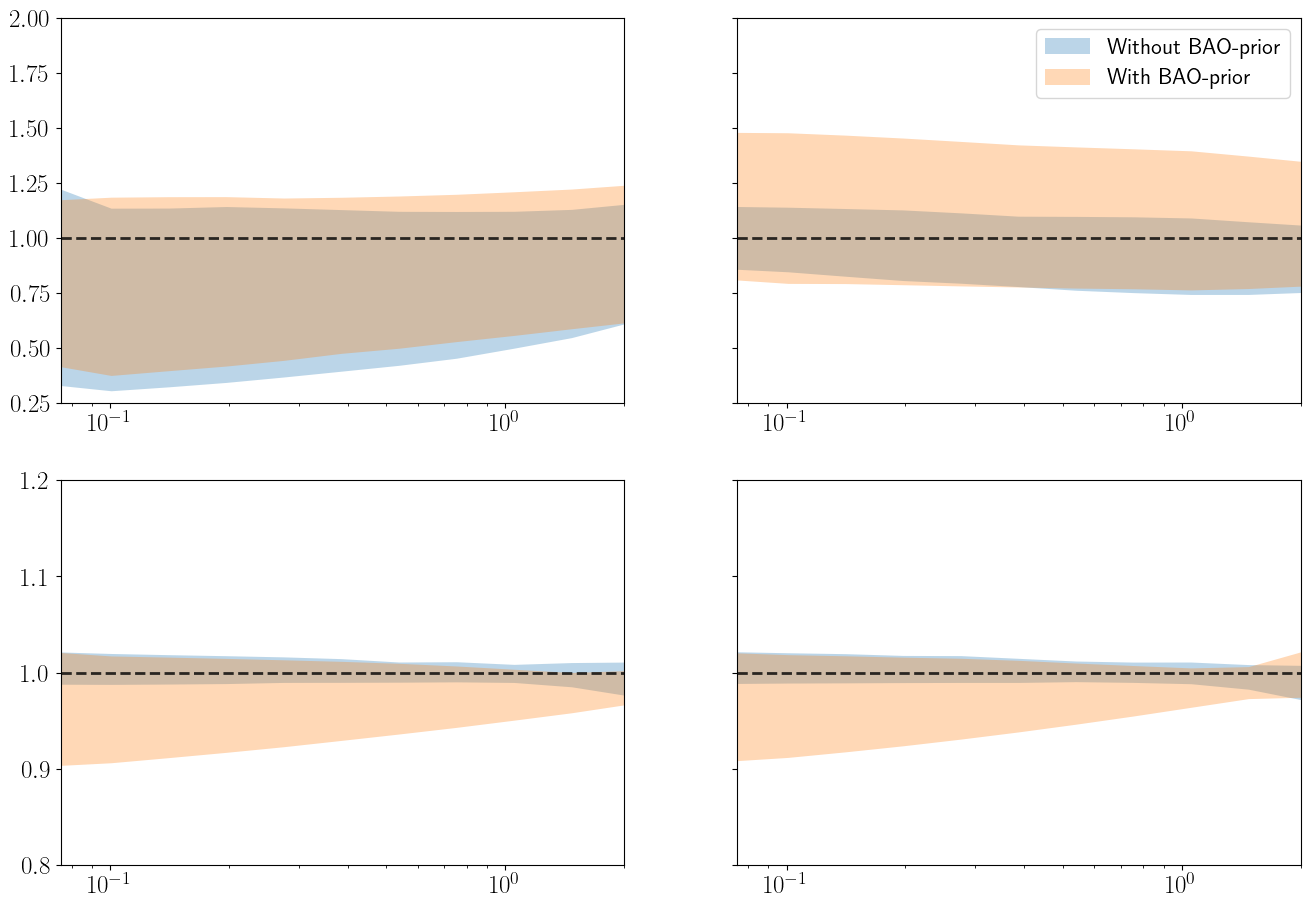

In [22]:
# --- Plotting Setup ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey='row') # Increased figure height for more space
# plt.style.use('seaborn-v0_8-whitegrid')



for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        # details = panel_details[row, col]
        
        ax.set_xscale('log')
        # ax.set_yscale('log')
        
        if row==0 and col==0:
            # ax.fill_between(r_array, rho_b_ratio_samps_min_gm, rho_b_ratio_samps_max_gm)
            ax.fill_between(r_array/r200c_fid[9], rho_b_ratio_samps_min_gm_bf/rho_baryon_mat_z0_fid[:,9], rho_b_ratio_samps_max_gm_bf/rho_baryon_mat_z0_fid[:,9], alpha=0.3)         
            ax.fill_between(r_array/r200c_fid[9], rho_b_ratio_samps_min_gm/rho_baryon_mat_z0_fid[:,9], rho_b_ratio_samps_max_gm/rho_baryon_mat_z0_fid[:,9], alpha=0.3)         
            ax.set_ylim(0.25, 2.0)
        if row==1 and col==0:
            # ax.fill_between(r_array, rho_m_ratio_samps_min_gm, rho_m_ratio_samps_max_gm)
            ax.fill_between(r_array/r200c_fid[9], rho_m_ratio_samps_min_gm_bf/rho_tot_mat_z0_fid[:,9], rho_m_ratio_samps_max_gm_bf/rho_tot_mat_z0_fid[:,9], alpha=0.3)            
            ax.fill_between(r_array/r200c_fid[9], rho_m_ratio_samps_min_gm/rho_tot_mat_z0_fid[:,9], rho_m_ratio_samps_max_gm/rho_tot_mat_z0_fid[:,9], alpha=0.3)
            ax.set_ylim(0.8, 1.2)
        
        if row==0 and col==1:
            # ax.fill_between(r_array, rho_b_ratio_samps_min_cm, rho_b_ratio_samps_max_cm)
            ax.fill_between(r_array/r200c_fid[14], rho_b_ratio_samps_min_cm_bf/rho_baryon_mat_z0_fid[:,14], rho_b_ratio_samps_max_cm_bf/rho_baryon_mat_z0_fid[:,14], alpha=0.3, label='Without BAO-prior')                   
            ax.fill_between(r_array/r200c_fid[14], rho_b_ratio_samps_min_cm/rho_baryon_mat_z0_fid[:,14], rho_b_ratio_samps_max_cm/rho_baryon_mat_z0_fid[:,14], alpha=0.3, label='With BAO-prior')       
            ax.set_ylim(0.25, 2.0)
            ax.legend(fontsize=16)
        if row==1 and col==1:
            # ax.fill_between(r_array, rho_m_ratio_samps_min_cm, rho_m_ratio_samps_max_cm)
            ax.fill_between(r_array/r200c_fid[14], rho_m_ratio_samps_min_cm_bf/rho_tot_mat_z0_fid[:,14], rho_m_ratio_samps_max_cm_bf/rho_tot_mat_z0_fid[:,14], alpha=0.3)            
            ax.fill_between(r_array/r200c_fid[14], rho_m_ratio_samps_min_cm/rho_tot_mat_z0_fid[:,14], rho_m_ratio_samps_max_cm/rho_tot_mat_z0_fid[:,14], alpha=0.3)
            ax.set_ylim(0.8, 1.2)
        
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        # ax.set_xlim(details['xlim'])
        ax.set_xlim(0.075, 2)
        
        ax.tick_params(axis='both', which='both', labelsize=18) # Increased tick font size
        # ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size




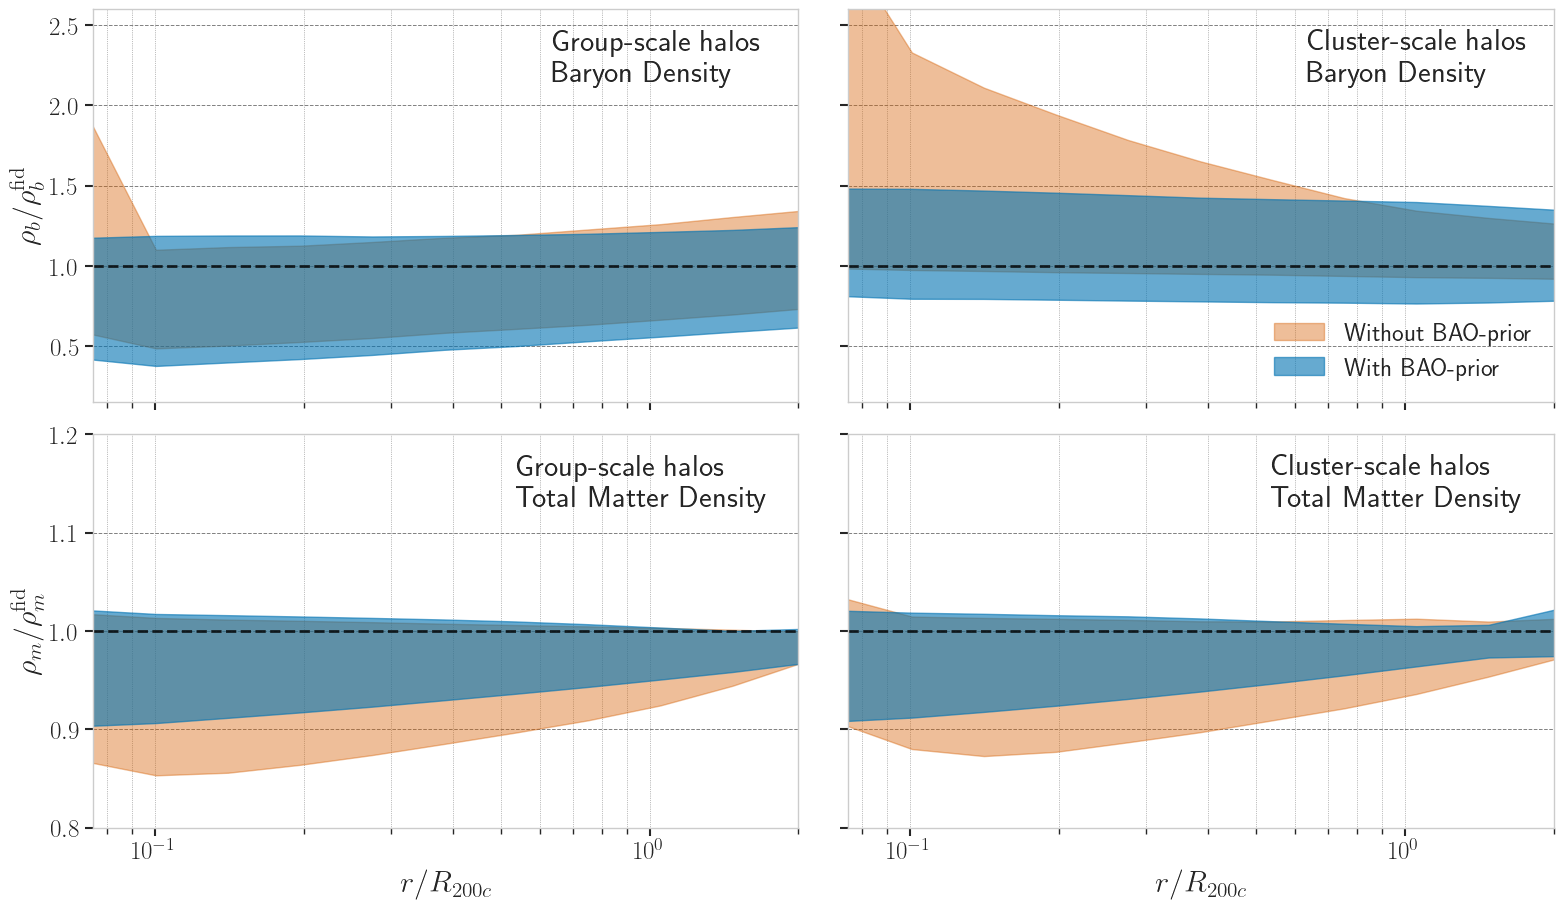

In [28]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey='row') # Increased figure height for more space

plt.style.use('seaborn-v0_8-whitegrid')

# Define colors for consistency and better aesthetics
color_with_bao = '#0072B2'  # A nice blue
color_without_bao = '#D55E00' # A complementary orange

# Create the figure and axes. `sharey='row'` is great for comparison.
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row', sharex=True)

# Add a main title for the entire figure
# fig.suptitle('Comparison of Density Profiles', fontsize=24, y=0.97)


# --- Loop Through Subplots ---
for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        
        # Set log scale for the x-axis
        ax.set_xscale('log')
        
        # --- NEW: Enable grids for both major and minor ticks on both axes ---
        # `which='both'` applies the grid to major and minor ticks.
        # We use different styles for x and y grids for clarity.
        ax.grid(which='major', axis='y', linestyle='--', linewidth=0.7, color='gray')
        ax.grid(which='both', axis='x', linestyle=':', linewidth=0.5, color='gray')

        # --- Set Y-Labels (using LaTeX for proper formatting) ---
        # This is done only for the first column since the y-axis is shared per row.
        if col == 0:
            if row == 0:
                # NEW: Set y-label for the top row
                ax.set_ylabel(r'$\rho_b / \rho_b^{\rm fid}$', fontsize=22)
            else:
                # NEW: Set y-label for the bottom row
                ax.set_ylabel(r'$\rho_m / \rho_m^{\rm fid}$', fontsize=22)

        # Set a title for each subplot for better context
        # if row == 0:
        #     ax.set_title(f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"} - Baryon Density', fontsize=20)
        # else:
        #     ax.set_title(f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"} - Total Matter Density', fontsize=20)


        # --- Plotting Data ---
        if row == 0 and col == 0:
            # Group GM, Baryon Density
            ax.fill_between(r_array/r200c_fid[9], rho_b_ratio_samps_min_gm_bf/rho_baryon_mat_z0_fid[:,9], rho_b_ratio_samps_max_gm_bf/rho_baryon_mat_z0_fid[:,9], alpha=0.4, color=color_without_bao)
            ax.fill_between(r_array/r200c_fid[9], rho_b_ratio_samps_min_gm/rho_baryon_mat_z0_fid[:,9], rho_b_ratio_samps_max_gm/rho_baryon_mat_z0_fid[:,9], alpha=0.6, color=color_with_bao)
            ax.set_ylim(0.15, 2.6)
            text = f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"}' + '\n' +  'Baryon Density'
            ax.text(0.65, 0.95, text, fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size
            
        if row == 1 and col == 0:
            # Group GM, Matter Density
            ax.fill_between(r_array/r200c_fid[9], rho_m_ratio_samps_min_gm_bf/rho_tot_mat_z0_fid[:,9], rho_m_ratio_samps_max_gm_bf/rho_tot_mat_z0_fid[:,9], alpha=0.4, color=color_without_bao)
            ax.fill_between(r_array/r200c_fid[9], rho_m_ratio_samps_min_gm/rho_tot_mat_z0_fid[:,9], rho_m_ratio_samps_max_gm/rho_tot_mat_z0_fid[:,9], alpha=0.6, color=color_with_bao)
            ax.set_ylim(0.8, 1.2)
            text = f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"}' + '\n' +  'Total Matter Density'
            ax.text(0.6, 0.95, text, fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size
            
        if row == 0 and col == 1:
            # Group CM, Baryon Density
            ax.fill_between(r_array/r200c_fid[14], rho_b_ratio_samps_min_cm_bf/rho_baryon_mat_z0_fid[:,14], rho_b_ratio_samps_max_cm_bf/rho_baryon_mat_z0_fid[:,14], alpha=0.4, color=color_without_bao, label='Without BAO-prior')
            ax.fill_between(r_array/r200c_fid[14], rho_b_ratio_samps_min_cm/rho_baryon_mat_z0_fid[:,14], rho_b_ratio_samps_max_cm/rho_baryon_mat_z0_fid[:,14], alpha=0.6, color=color_with_bao, label='With BAO-prior')
            ax.set_ylim(0.15, 2.6)
            ax.legend(fontsize=18, frameon=False, shadow=True, loc='lower right') # Made legend prettier
            text = f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"}' + '\n' +  'Baryon Density'
            ax.text(0.65, 0.95, text, fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        
        if row == 1 and col == 1:
            # Group CM, Matter Density
            ax.fill_between(r_array/r200c_fid[14], rho_m_ratio_samps_min_cm_bf/rho_tot_mat_z0_fid[:,14], rho_m_ratio_samps_max_cm_bf/rho_tot_mat_z0_fid[:,14], alpha=0.4, color=color_without_bao)
            ax.fill_between(r_array/r200c_fid[14], rho_m_ratio_samps_min_cm/rho_tot_mat_z0_fid[:,14], rho_m_ratio_samps_max_cm/rho_tot_mat_z0_fid[:,14], alpha=0.6, color=color_with_bao)
            ax.set_ylim(0.8, 1.2)
            text = f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"}' + '\n' +  'Total Matter Density'
            ax.text(0.6, 0.95, text, fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        # --- General Aesthetics for all subplots ---
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(0.075, 2)
        
        # Increase tick font size for readability
        ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.5)
        ax.tick_params(axis='both', which='minor', length=4, width=1)

# Set a shared x-label for the bottom row plots
for col in range(2):
    axes[1, col].set_xlabel(r'$r/R_{200c}$', fontsize=22)

# Adjust layout to prevent labels/titles from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# plt.savefig('')
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
plt.savefig(os.path.join(sdir, "profiles_inference_comparison.pdf"), bbox_inches="tight", dpi=200)


# Display the plot
plt.show()




In [ ]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'

probes_forecast = 'kk,gg,gk'
# probes_forecast = 'kk,gg,gk,ge'
# probes_forecast = 'ky,kk,gg,gy,gk,ge'
probes_forecast = probes_forecast.split(',')
probes_forecast_all_str = '_'.join(probes_forecast)
scval = 4000

fname = ldir + f'infer_v5_{probes_forecast_all_str}_scval_{scval}_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
# fname = ldir + 'infer_v5_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True_nsel_1024.pkl'
df = pk.load(open(fname, 'rb'))
# df.keys()
# df['rho_b_model_all_samp'].shape
r_array = df['r_array']
M_array = df['M_array']
rho_b_model_all_samp = df['rho_b_model_all_samp']
rho_tot_model_all_samp = df['rho_tot_model_all_samp']

rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, 9]
rho_b_ratio_samps_min_gm_bf = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
rho_b_ratio_samps_max_gm_bf = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, 9]
rho_m_ratio_samps_min_gm_bf = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
rho_m_ratio_samps_max_gm_bf = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)

rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, 14]
rho_b_ratio_samps_min_cm_bf = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
rho_b_ratio_samps_max_cm_bf = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, 14]
rho_m_ratio_samps_min_cm_bf = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
rho_m_ratio_samps_max_cm_bf = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)






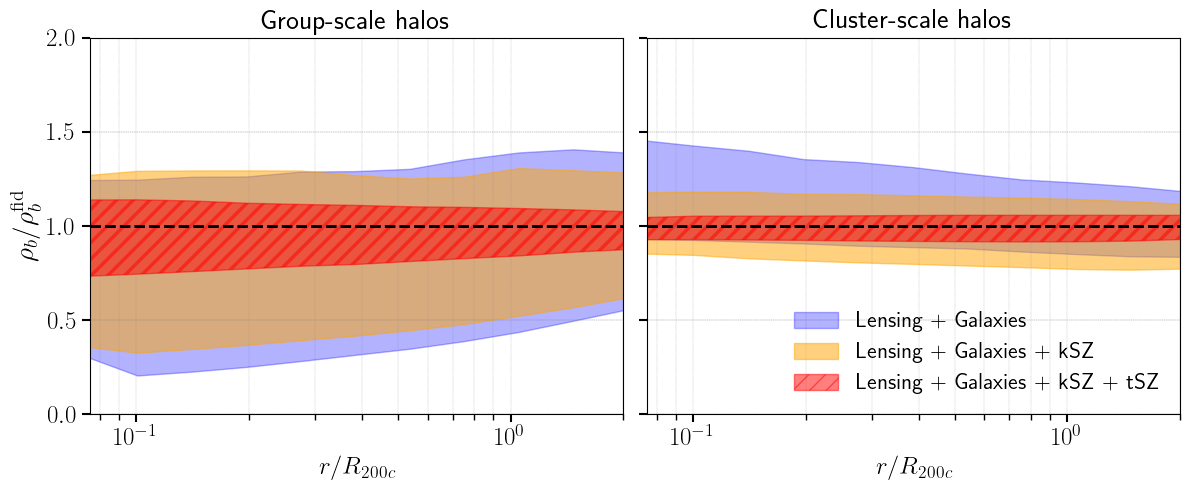

In [25]:
fig, ax_all = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# adjust the space between the two subplots
plt.subplots_adjust(wspace=0.1)

# probes_forecast = 'kk,gg,gk'
# probes_forecast = 'kk,gg,gk,ge'
# probes_forecast = 'ky,kk,gg,gy,gk,ge'

probes_forecast_all = ['kk,gg,gk', 'kk,gg,gk,ge', 'ky,kk,gg,gy,gk,ge']
labels_all = ['Lensing + Galaxies', 'Lensing + Galaxies + kSZ', 'Lensing + Galaxies + kSZ + tSZ']
colors_all = ['blue', 'orange', 'red']
hatch_all = ['', '', '//']
alpha_all = [0.3, 0.5, 0.5]
ind_g = 9
ind_c = 14


for jax in range(2):

    if jax == 0:
        ind_plot = ind_g
    if jax == 1:
        ind_plot = ind_c
    ax = ax_all[jax]

    for jp, probes_forecast in enumerate(probes_forecast_all):

        probes_forecast = probes_forecast.split(',')
        probes_forecast_all_str = '_'.join(probes_forecast)
        scval = 4000

        fname = ldir + f'infer_v5_{probes_forecast_all_str}_scval_{scval}_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
        # fname = ldir + 'infer_v5_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True_nsel_1024.pkl'
        df = pk.load(open(fname, 'rb'))
        # df.keys()
        # df['rho_b_model_all_samp'].shape
        r_array = df['r_array']
        M_array = df['M_array']
        rho_b_model_all_samp = df['rho_b_model_all_samp']
        rho_tot_model_all_samp = df['rho_tot_model_all_samp']

        rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, ind_g]
        rho_b_ratio_samps_min_gm_bf = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
        rho_b_ratio_samps_max_gm_bf = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

        rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, ind_g]
        rho_m_ratio_samps_min_gm_bf = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
        rho_m_ratio_samps_max_gm_bf = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)

        rho_b_ratio_samps_to_plot = rho_b_model_all_samp[:, :, ind_c]
        rho_b_ratio_samps_min_cm_bf = np.percentile(rho_b_ratio_samps_to_plot, 16, axis=0)
        rho_b_ratio_samps_max_cm_bf = np.percentile(rho_b_ratio_samps_to_plot, 84, axis=0)

        rho_m_ratio_samps_to_plot = rho_tot_model_all_samp[:, :, ind_c]
        rho_m_ratio_samps_min_cm_bf = np.percentile(rho_m_ratio_samps_to_plot, 16, axis=0)
        rho_m_ratio_samps_max_cm_bf = np.percentile(rho_m_ratio_samps_to_plot, 84, axis=0)

        if ind_plot == ind_g:
            ax.fill_between(r_array/r200c_fid[ind_plot], rho_b_ratio_samps_min_gm_bf/rho_baryon_mat_z0_fid[:,ind_plot], rho_b_ratio_samps_max_gm_bf/rho_baryon_mat_z0_fid[:,ind_plot], 
                            alpha=alpha_all[jp], color=colors_all[jp], hatch=hatch_all[jp], hatch_linewidth=2.5, label=labels_all[jp])
        if ind_plot == ind_c:
            ax.fill_between(r_array/r200c_fid[ind_plot], rho_b_ratio_samps_min_cm_bf/rho_baryon_mat_z0_fid[:,ind_plot], rho_b_ratio_samps_max_cm_bf/rho_baryon_mat_z0_fid[:,ind_plot], 
                            alpha=alpha_all[jp], color=colors_all[jp], hatch=hatch_all[jp], hatch_linewidth=2.5, label=labels_all[jp])
        ax.set_ylim(0.0, 2.0)
        # ax.legend(fontsize=18, frameon=False, shadow=True, loc='lower right') # Made legend prettier
        # text = f'{"Group-scale halos" if col == 0 else "Cluster-scale halos"}' + '\n' +  'Baryon Density'
        # ax.text(0.65, 0.95, text, fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        ax.set_xscale('log')
        
        # --- NEW: Enable grids for both major and minor ticks on both axes ---
        # `which='both'` applies the grid to major and minor ticks.
        # We use different styles for x and y grids for clarity.
        ax.grid(which='major', axis='y', linestyle='--', linewidth=0.3, color='gray')
        ax.grid(which='both', axis='x', linestyle=':', linewidth=0.3, color='gray')
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(0.075, 2)
        
        # Increase tick font size for readability
        ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.5)
        ax.tick_params(axis='both', which='minor', length=4, width=1)
        ax.set_xlabel(r'$r/R_{200c}$', fontsize=18)
        if jax == 0:
            ax.set_ylabel(r'$\rho_b / \rho_b^{\rm fid}$', fontsize=20)
            ax.set_title('Group-scale halos', fontsize=20)
        if jax == 1:
            ax.legend(fontsize=16, frameon=False, shadow=True, loc='lower right') # Made legend prettier
            ax.set_title('Cluster-scale halos', fontsize=20)
plt.tight_layout()
plt.savefig('rhob_plot_proposal.pdf', bbox_inches="tight", dpi=200)
    # Apply common settings to both subplots
    # for ax in axes:
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    # ax.set_xlim(800, 1e4)
    # ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=18)
    # ax.grid(which="both", linestyle="--", linewidth=0.5)
    # ax.tick_params(axis="both", which="major", labelsize=15)

    # # Set the shared y-axis label
    # ax.set_ylabel(r"FoM($\Omega_{\rm m}, \sigma_8$)", fontsize=18)
    # ax.set_ylim(9e3, 2e5)

    # # --- Create a single, shared legend below the plots ---
    # handles, labels = [], []
    # # for ax in axes[0]:
    # h, l = ax.get_legend_handles_labels()
    # handles.extend(h)
    # labels.extend(l)

    # fig.legend(
    #     handles, 
    #     labels, 
    #     loc='upper right',             # Position the legend at the bottom center
    #     bbox_to_anchor=(1.55, 0.65),    # Anchor it slightly below the plot area
    #     frameon=False, 
    #     fontsize=15,
    #     ncol=1              # Set number of columns to match items, creating a single row
    # )

    # # Adjust subplot layout to make room for the bottom legend
    # fig.subplots_adjust(bottom=0.25)

    # # --- Save the Figure ---
    # sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
    # os.makedirs(sdir, exist_ok=True)
    # plt.savefig(os.path.join(sdir, "fom_comparison_proposal.pdf"), bbox_inches="tight")

    # plt.show()





